In [1]:
import pandas as pd

In [6]:
df = pd.read_csv('../climate_data_aggregated_by_month_and_district.csv')

In [7]:
df

,feature,month,tp,e,ro,t2m,stl1,d2m,stl2,swvl1,swvl2,cvh,cvl,slt
0,A & N Islands_Nicobars,1,0.155895,-0.145155,0.000000,299.957974,301.395849,296.205143,301.395933,7.828219e-07,9.263556e-07,0.000000,0.000000,0.00
1,A & N Islands_Nicobars,2,0.073241,-0.127951,0.000000,300.347773,301.663718,296.253400,301.655300,-1.457989e-06,-8.020846e-08,0.000000,0.000000,0.00
2,A & N Islands_Nicobars,3,0.107033,-0.118626,0.000000,300.728570,302.288358,296.591939,302.276559,-1.509114e-06,-8.345849e-07,0.000000,0.000000,0.00
3,A & N Islands_Nicobars,4,0.134209,-0.101045,0.000000,300.984711,302.984163,297.179667,302.976795,-2.279712e-07,2.165511e-06,0.000000,0.000000,0.00
4,A & N Islands_Nicobars,5,0.265185,-0.136944,0.000000,300.947370,302.708544,297.735900,302.719828,3.265345e-07,-1.801931e-06,0.000000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9271,West Bengal_Purulia,8,0.286655,-0.108605,0.091595,301.316108,301.991658,298.498164,301.356652,4.016572e-01,4.017722e-01,0.317097,0.668795,2.25
9272,West Bengal_Purulia,9,0.232007,-0.106522,0.097131,301.040230,301.816350,298.070948,301.156227,3.893341e-01,3.896617e-01,0.317097,0.668795,2.25
9273,West Bengal_Purulia,10,0.092837,-0.102173,0.072248,299.260643,300.044396,294.979955,299.625393,3.149695e-01,3.254036e-01,0.317097,0.668795,2.25
9274,West Bengal_Purulia,11,0.008047,-0.069953,0.029248,295.191450,296.073610,289.408941,296.285416,2.077455e-01,2.354825e-01,0.317097,0.668795,2.25


In [21]:
import pandas as pd
import numpy as np
from scipy import stats

def extract_climate_features(df):
    """
    Extract climatological features from monthly time series data.
    
    Parameters:
    df: DataFrame with columns: feature, month, tp, e, ro, t2m, stl1, d2m, stl2, swvl1, swvl2, cvh, cvl, slt
    
    Returns:
    DataFrame with extracted features per location
    """
    
    # Extract location identifier (assuming 'feature' column contains location)
    df['location'] = df['feature']
    
    results = []
    
    for location, group in df.groupby('location'):
        features = {}
        features['location'] = location
        
        # Sort by month to ensure correct order
        group = group.sort_values('month').reset_index(drop=True)
        
        # ===== PRECIPITATION (tp) FEATURES =====
        tp = group['tp'].values
        features['tp_annual_total'] = np.sum(tp)
        
        # Seasonality
        features['tp_amplitude'] = np.max(tp) - np.min(tp)
        peak_month = group.loc[group['tp'].idxmax(), 'month']
        features['tp_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
        features['tp_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
        
        # Extremes
        features['tp_P90'] = np.percentile(tp, 90)
        features['tp_P10'] = np.percentile(tp, 10)
        
        # Precipitation Concentration Index (PCI)
        # PCI = sum(monthly_precip^2) / (sum(monthly_precip))^2 * 100
        tp_sum = np.sum(tp)
        features['tp_PCI'] = (np.sum(tp**2) / (tp_sum**2)) * 100 if tp_sum > 0 else 0
        
        # Second highest rainy month
        sorted_idx = np.argsort(tp)
        second_peak_month = group.loc[sorted_idx[-2], 'month']
        features['tp_second_peak_month_sin'] = np.sin(2 * np.pi * second_peak_month / 12)
        features['tp_second_peak_month_cos'] = np.cos(2 * np.pi * second_peak_month / 12)
        
        # Variability
        features['tp_CV'] = np.std(tp) / np.mean(tp) if np.mean(tp) > 0 else 0
        
        # Fourier shape and harmonics ratio
        fft = np.fft.fft(tp)
        features['tp_fourier_comp1_real'] = np.real(fft[1])
        features['tp_fourier_comp1_imag'] = np.imag(fft[1])
        features['tp_a2_a1_ratio'] = np.abs(fft[2]) / np.abs(fft[1]) if np.abs(fft[1]) > 0 else 0
        
        # ===== TEMPERATURE (t2m) FEATURES =====
        t2m = group['t2m'].values
        features['t2m_annual_mean'] = np.mean(t2m)
        
        # Seasonality
        features['t2m_amplitude'] = np.max(t2m) - np.min(t2m)
        peak_month = group.loc[group['t2m'].idxmax(), 'month']
        features['t2m_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
        features['t2m_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
        min_month = group.loc[group['t2m'].idxmin(), 'month']
        features['t2m_min_month_sin'] = np.sin(2 * np.pi * min_month / 12)
        features['t2m_min_month_cos'] = np.cos(2 * np.pi * min_month / 12)
        
        # Extremes
        features['t2m_P90'] = np.percentile(t2m, 90)
        features['t2m_P10'] = np.percentile(t2m, 10)
        
        # Variability
        features['t2m_std'] = np.std(t2m)
        # GDD (Growing Degree Days) - sum of temps above base (typically 10°C = 283.15K)
        features['t2m_GDD'] = np.sum(np.maximum(t2m - 283.15, 0))
        
        # Fourier shape and harmonics ratio
        fft = np.fft.fft(t2m)
        features['t2m_fourier_comp1_real'] = np.real(fft[1])
        features['t2m_fourier_comp1_imag'] = np.imag(fft[1])
        features['t2m_a2_a1_ratio'] = np.abs(fft[2]) / np.abs(fft[1]) if np.abs(fft[1]) > 0 else 0
        
        # ===== EVAPORATION (e) FEATURES =====
        e = group['e'].values
        features['e_annual_mean'] = np.mean(e)
        
        # Seasonality
        features['e_amplitude'] = np.max(e) - np.min(e)
        peak_month = group.loc[group['e'].idxmax(), 'month']
        features['e_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
        features['e_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
        
        # Extremes
        features['e_P90'] = np.percentile(e, 90)
        features['e_P10'] = np.percentile(e, 10)
        
        # Ratios
        features['e_evapor_rainfall_ratio'] = np.abs(np.sum(e)) / np.sum(tp) if np.sum(tp) > 0 else 0
        
        # ===== RUNOFF (ro) FEATURES =====
        if 'ro' in group.columns:
            ro = group['ro'].values
            features['ro_annual_total'] = np.sum(ro)
            
            # Seasonality
            features['ro_amplitude'] = np.max(ro) - np.min(ro)
            peak_month = group.loc[group['ro'].idxmax(), 'month']
            features['ro_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
            features['ro_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
            
            # Extremes
            features['ro_P90'] = np.percentile(ro, 90)
            features['ro_P10'] = np.percentile(ro, 10)
            
            # Ratios
            features['ro_runoff_efficiency'] = np.sum(ro) / np.sum(tp) if np.sum(tp) > 0 else 0
        
        # ===== DEWPOINT (d2m) FEATURES =====
        d2m = group['d2m'].values
        features['d2m_annual_mean'] = np.mean(d2m)
        
        # Seasonality
        features['d2m_amplitude'] = np.max(d2m) - np.min(d2m)
        peak_month = group.loc[group['d2m'].idxmax(), 'month']
        features['d2m_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
        features['d2m_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
        
        # Extremes
        features['d2m_P90'] = np.percentile(d2m, 90)
        features['d2m_P10'] = np.percentile(d2m, 10)
        
        # Misc
        features['d2m_humidity_index'] = np.mean(t2m - d2m)
        
        # ===== SOIL TEMPERATURE (stl1, stl2) FEATURES =====
        for var in ['stl1', 'stl2']:
            vals = group[var].values
            features[f'{var}_mean'] = np.mean(vals)
            features[f'{var}_amplitude'] = np.max(vals) - np.min(vals)
            peak_month = group.loc[group[var].idxmax(), 'month']
            features[f'{var}_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
            features[f'{var}_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
            features[f'{var}_P90'] = np.percentile(vals, 90)
            features[f'{var}_P10'] = np.percentile(vals, 10)
            features[f'{var}_std'] = np.std(vals)
            fft = np.fft.fft(vals)
            features[f'{var}_fourier_comp1_real'] = np.real(fft[1])
            features[f'{var}_fourier_comp1_imag'] = np.imag(fft[1])
        
        # ===== SOIL WATER VOLUME RATIO (swvl1, swvl2) FEATURES =====
        for var in ['swvl1', 'swvl2']:
            vals = group[var].values
            features[f'{var}_mean'] = np.mean(vals)
            features[f'{var}_amplitude'] = np.max(vals) - np.min(vals)
            peak_month = group.loc[group[var].idxmax(), 'month']
            features[f'{var}_peak_month_sin'] = np.sin(2 * np.pi * peak_month / 12)
            features[f'{var}_peak_month_cos'] = np.cos(2 * np.pi * peak_month / 12)
            
            # Dry months (below median)
            median = np.median(vals)
            dry_mask = vals < median
            features[f'{var}_dry_mean'] = np.mean(vals[dry_mask]) if np.any(dry_mask) else 0
            features[f'{var}_wet_mean'] = np.mean(vals[~dry_mask]) if np.any(~dry_mask) else 0
            
            features[f'{var}_P90'] = np.percentile(vals, 90)
            features[f'{var}_P10'] = np.percentile(vals, 10)
            
            fft = np.fft.fft(vals)
            features[f'{var}_fourier_comp1_real'] = np.real(fft[1])
            features[f'{var}_fourier_comp1_imag'] = np.imag(fft[1])
        
        # ===== VEGETATION COVER (cvh, cvl) - Categorical =====
        # cvh = high vegetation cover, cvl = low vegetation cover
        # These are categorical, so we just take the mode (most common value)
        features['cvh'] = group['cvh'].mode()[0] if len(group['cvh'].mode()) > 0 else group['cvh'].iloc[0]
        features['cvl'] = group['cvl'].mode()[0] if len(group['cvl'].mode()) > 0 else group['cvl'].iloc[0]
        
        # ===== SOIL TYPE (slt) =====
        features['slt'] = group['slt'].iloc[0]  # Constant per location
        
        results.append(features)
    
    return pd.DataFrame(results)


features_df = extract_climate_features(df)
features_df

,location,tp_annual_total,tp_amplitude,tp_peak_month_sin,tp_peak_month_cos,tp_P90,tp_P10,tp_PCI,tp_second_peak_month_sin,tp_second_peak_month_cos,...,swvl2_peak_month_cos,swvl2_dry_mean,swvl2_wet_mean,swvl2_P90,swvl2_P10,swvl2_fourier_comp1_real,swvl2_fourier_comp1_imag,cvh,cvl,slt
0,A & N Islands_Nicobars,2.433050,0.238634,-0.5,8.660254e-01,0.274067,0.109750,9.314572,-2.449294e-16,1.0,...,-5.000000e-01,-5.379768e-07,0.000001,0.000002,-0.000002,-8.128728e-07,0.000001,0.000000,0.000000,0.000000
1,A & N Islands_North And Middle Andaman,2.228415,0.338552,-1.0,-1.836970e-16,0.338330,0.032821,12.573580,1.224647e-16,-1.0,...,-1.836970e-16,7.340073e-02,0.122475,0.125152,0.058057,-1.515068e-01,0.169060,0.097324,0.141098,0.964286
2,A & N Islands_South Andamans,2.322077,0.315515,-1.0,-1.836970e-16,0.327192,0.046093,11.397692,1.224647e-16,-1.0,...,-1.836970e-16,1.072454e-02,0.016534,0.016803,0.008823,-1.881944e-02,0.019623,0.009017,0.024268,0.176471
3,Andhra Pradesh_Alluri Sitharama Raju,1.659993,0.355810,-0.5,-8.660254e-01,0.336767,0.013673,15.803012,-8.660254e-01,-0.5,...,-5.000000e-01,2.199521e-01,0.369967,0.406345,0.196211,-5.193792e-01,0.454063,0.737434,0.258645,3.056075
4,Andhra Pradesh_Anakapalli,1.294318,0.238247,-0.5,-8.660254e-01,0.246516,0.011695,14.782391,-8.660254e-01,-0.5,...,-1.836970e-16,1.462159e-01,0.269308,0.301735,0.129461,-3.896110e-01,0.417390,0.403020,0.543015,2.606060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,West Bengal_Murshidabad,1.545324,0.292996,-0.5,-8.660254e-01,0.286400,0.010403,14.941064,1.224647e-16,-1.0,...,-5.000000e-01,2.307294e-01,0.356739,0.393919,0.213690,-4.869066e-01,0.311817,0.333241,0.628573,2.833333
769,West Bengal_Nadia,1.603194,0.295587,-0.5,-8.660254e-01,0.291820,0.017111,14.435502,1.224647e-16,-1.0,...,-5.000000e-01,2.311132e-01,0.357357,0.393644,0.217108,-4.914137e-01,0.315944,0.082477,0.907967,3.756757
770,West Bengal_Paschim Bardhaman,1.345292,0.275459,-0.5,-8.660254e-01,0.261445,0.011462,15.760783,-8.660254e-01,-0.5,...,-5.000000e-01,2.130301e-01,0.342246,0.389390,0.196783,-4.744852e-01,0.379235,0.344329,0.655025,2.000000
771,West Bengal_Purba Bardhaman,1.512000,0.291786,-0.5,-8.660254e-01,0.275280,0.014464,14.813754,-8.660254e-01,-0.5,...,-5.000000e-01,2.284690e-01,0.353991,0.393475,0.209731,-4.889073e-01,0.327378,0.354676,0.609256,2.000000


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate location column
locations = features_df['location'].values

# Get all feature columns (exclude location and categorical variables)
feature_cols = [col for col in features_df.columns 
                if col not in ['location', 'cvh', 'cvl', 'slt']]

# Extract features
X = features_df[feature_cols].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

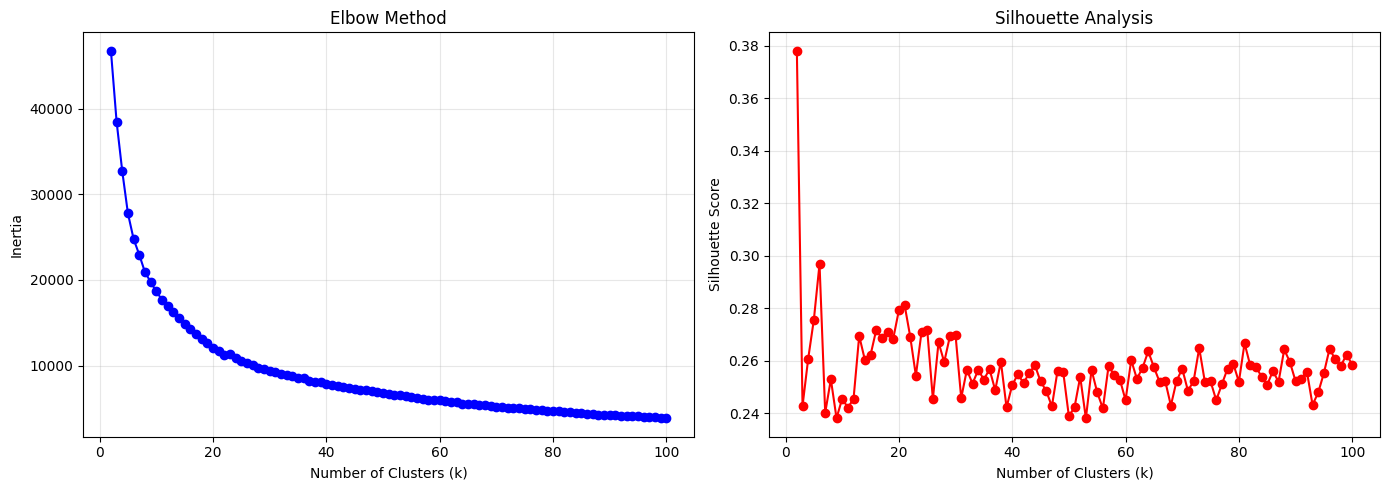

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

max_k = 100
inertias = []
silhouette_scores = []
k_range = range(2, max_k + 1)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_temp))

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



K-Means Evaluation:
  Number of clusters: 15
  Silhouette Score: 0.2621
  Davies-Bouldin Index: 1.3285
  Calinski-Harabasz Index: 185.76


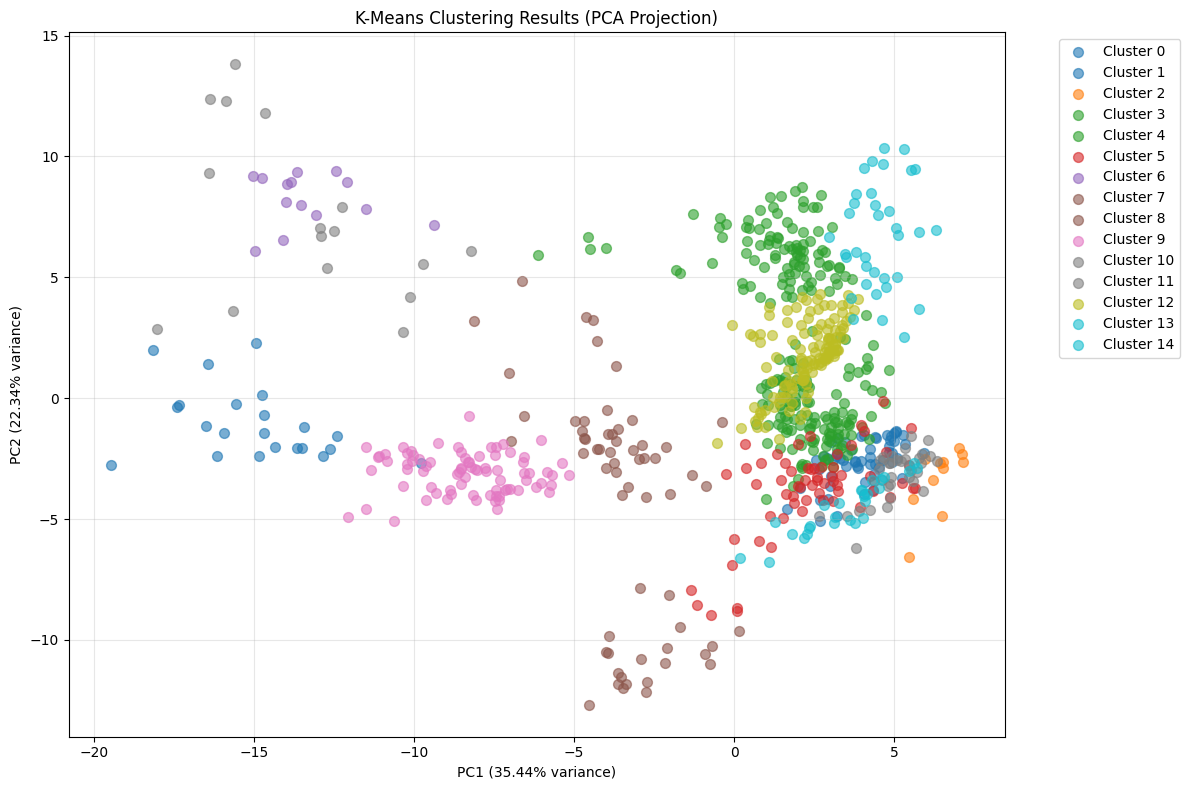


K-Means Cluster Summary:

Cluster 0:
  Size: 57 locations
  Sample locations: Andhra Pradesh_Alluri Sitharama Raju, Andhra Pradesh_East Godavari, Andhra Pradesh_Eluru, Andhra Pradesh_Guntur, Andhra Pradesh_Kurnool
  Avg annual rainfall: 1.02
  Avg annual temp: 300.47 K
  Avg PCI: 18.05

Cluster 1:
  Size: 22 locations
  Sample locations: Arunachal Pradesh_Anjaw, Arunachal Pradesh_Dibang Valley, Arunachal Pradesh_East Kameng, Arunachal Pradesh_Kamle, Arunachal Pradesh_Kra Daadi
  Avg annual rainfall: 4.39
  Avg annual temp: 286.52 K
  Avg PCI: 12.09

Cluster 2:
  Size: 11 locations
  Sample locations: A & N Islands_Nicobars, A & N Islands_North And Middle Andaman, A & N Islands_South Andamans, Puducherry_Karaikal, Puducherry_Pondicherry
  Avg annual rainfall: 1.47
  Avg annual temp: 301.19 K
  Avg PCI: 13.80

Cluster 3:
  Size: 97 locations
  Sample locations: Chandigarh_Chandigarh, Delhi_Central, Delhi_New Delhi, Delhi_North, Delhi_North West
  Avg annual rainfall: 0.82
  Avg annual t

In [29]:
n_clusters = 15

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate K-Means
print("\nK-Means Evaluation:")
print(f"  Number of clusters: {len(np.unique(kmeans_labels))}")

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {kmeans_calinski_harabasz:.2f}")

# Visualize K-Means with PCA
pca_kmeans = PCA(n_components=2)
X_pca_kmeans = pca_kmeans.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label in range(n_clusters):
    mask = kmeans_labels == label
    plt.scatter(X_pca_kmeans[mask, 0], X_pca_kmeans[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_kmeans.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_kmeans.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K-Means cluster summary
kmeans_df = features_df.copy()
kmeans_df['cluster'] = kmeans_labels

print("\nK-Means Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(kmeans_df['cluster'].unique()):
    cluster_data = kmeans_df[kmeans_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_annual_total'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['t2m_annual_mean'].mean():.2f} K")
    print(f"  Avg PCI: {cluster_data['tp_PCI'].mean():.2f}")


In [32]:
# separate location column into state and district from underscore in the kmeans_df
kmeans_df[['state', 'district']] = kmeans_df['location'].str.split('_', expand=True)
kmeans_df.to_csv('kmeans_clustering_results_new.csv', index=False)

In [33]:
comparison_df = pd.read_csv('for_comparison.csv')

In [34]:
comparison_df

,district,label,label_name
0,A & N Islands_Nicobars,15,Islands Region
1,A & N Islands_North And Middle Andaman,15,Islands Region
2,A & N Islands_South Andamans,15,Islands Region
3,Andhra Pradesh_Alluri Sitharama Raju,11,East Coast Plains and Hills Region
4,Andhra Pradesh_Anakapalli,11,East Coast Plains and Hills Region
...,...,...,...
768,West Bengal_Murshidabad,3,Lower Gangetic Plains Region
769,West Bengal_Nadia,3,Lower Gangetic Plains Region
770,West Bengal_Paschim Bardhaman,3,Lower Gangetic Plains Region
771,West Bengal_Purba Bardhaman,3,Lower Gangetic Plains Region


In [37]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(comparison_df['label'], kmeans_df['cluster'])

0.3974863991665298


GMM Evaluation:
  Number of clusters: 15
  Silhouette Score: 0.2428
  Davies-Bouldin Index: 1.3590
  Calinski-Harabasz Index: 179.50


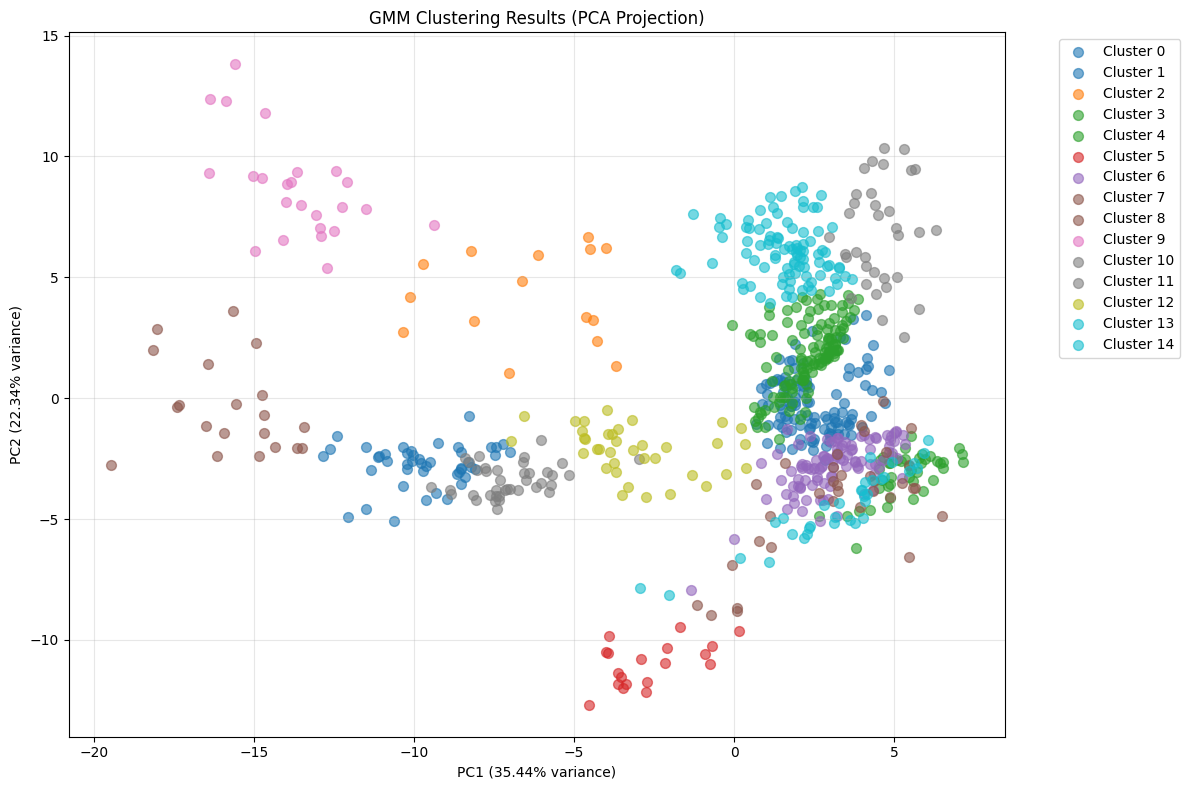


GMM Cluster Summary:

Cluster 0:
  Size: 110 locations
  Sample locations: Chhattisgarh_Baloda Bazar, Chhattisgarh_Balrampur, Chhattisgarh_Bemetara, Chhattisgarh_Bilaspur, Chhattisgarh_Durg
  Avg annual rainfall: 1.13
  Avg annual temp: 299.15 K
  Avg PCI: 23.70

Cluster 1:
  Size: 46 locations
  Sample locations: Arunachal Pradesh_Changlang, Arunachal Pradesh_East Siang, Arunachal Pradesh_Itanagar Capital Complex, Arunachal Pradesh_Kamle, Arunachal Pradesh_Leparada
  Avg annual rainfall: 2.89
  Avg annual temp: 293.69 K
  Avg PCI: 13.58

Cluster 2:
  Size: 15 locations
  Sample locations: Himachal Pradesh_Kangra, Himachal Pradesh_Mandi, Himachal Pradesh_Shimla, Himachal Pradesh_Sirmaur, Jammu & Kashmir_Kathua
  Avg annual rainfall: 1.69
  Avg annual temp: 288.90 K
  Avg PCI: 15.24

Cluster 3:
  Size: 43 locations
  Sample locations: A & N Islands_Nicobars, Andhra Pradesh_Annamayya, Andhra Pradesh_Chittoor, Andhra Pradesh_Prakasam, Andhra Pradesh_Spsr Nellore
  Avg annual rainfall: 1.

In [38]:
gmm = GaussianMixture(n_components=n_clusters, random_state=42, 
                      covariance_type='full', n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)

# Evaluate GMM
print("\nGMM Evaluation:")
print(f"  Number of clusters: {len(np.unique(gmm_labels))}")

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_davies_bouldin = davies_bouldin_score(X_scaled, gmm_labels)
gmm_calinski_harabasz = calinski_harabasz_score(X_scaled, gmm_labels)

print(f"  Silhouette Score: {gmm_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {gmm_calinski_harabasz:.2f}")

# Visualize GMM with PCA
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

for label in range(n_clusters):
    mask = gmm_labels == label
    plt.scatter(X_pca_gmm[mask, 0], X_pca_gmm[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_gmm.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_gmm.explained_variance_ratio_[1]:.2%} variance)')
plt.title('GMM Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GMM cluster summary
gmm_df = features_df.copy()
gmm_df['cluster'] = gmm_labels

print("\nGMM Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(gmm_df['cluster'].unique()):
    cluster_data = gmm_df[gmm_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_annual_total'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['t2m_annual_mean'].mean():.2f} K")
    print(f"  Avg PCI: {cluster_data['tp_PCI'].mean():.2f}")


In [39]:
gmm_df[['state', 'district']] = gmm_df['location'].str.split('_', expand=True)
gmm_df.to_csv('gmm_clustering_results_new.csv', index=False)

adjusted_rand_score(comparison_df['label'], gmm_df['cluster'])

0.35941484639879145


Hierarchical Evaluation:
  Number of clusters: 15
  Silhouette Score: 0.2611
  Davies-Bouldin Index: 1.3233
  Calinski-Harabasz Index: 174.65


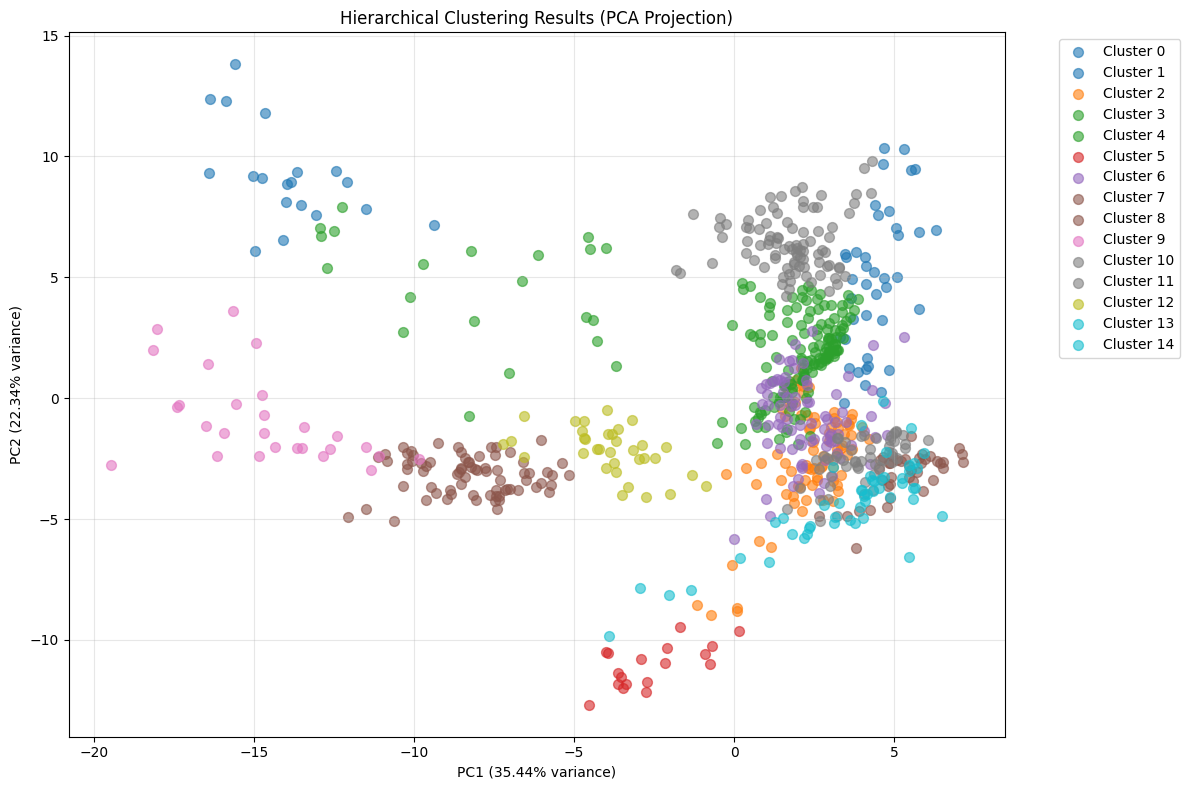


Hierarchical Cluster Summary:

Cluster 0:
  Size: 19 locations
  Sample locations: Himachal Pradesh_Kinnaur, Himachal Pradesh_Lahul And Spiti, Jammu & Kashmir_Anantnag, Jammu & Kashmir_Bandipora, Jammu & Kashmir_Baramulla
  Avg annual rainfall: 1.59
  Avg annual temp: 277.01 K
  Avg PCI: 9.82

Cluster 1:
  Size: 40 locations
  Sample locations: Gujarat_Ahmadabad, Gujarat_Anand, Gujarat_Banas Kantha, Gujarat_Gandhinagar, Gujarat_Jamnagar
  Avg annual rainfall: 0.55
  Avg annual temp: 299.64 K
  Avg PCI: 25.52

Cluster 2:
  Size: 84 locations
  Sample locations: Andhra Pradesh_Parvathipuram Manyam, Andhra Pradesh_Vizianagaram, Chhattisgarh_Balod, Chhattisgarh_Baloda Bazar, Chhattisgarh_Balrampur
  Avg annual rainfall: 1.57
  Avg annual temp: 298.99 K
  Avg PCI: 19.27

Cluster 3:
  Size: 140 locations
  Sample locations: Bihar_Araria, Bihar_Arwal, Bihar_Aurangabad, Bihar_Banka, Bihar_Begusarai
  Avg annual rainfall: 1.19
  Avg annual temp: 298.57 K
  Avg PCI: 19.41

Cluster 4:
  Size: 21

In [40]:
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

# Evaluate Hierarchical
print("\nHierarchical Evaluation:")
print(f"  Number of clusters: {len(np.unique(hier_labels))}")

hier_silhouette = silhouette_score(X_scaled, hier_labels)
hier_davies_bouldin = davies_bouldin_score(X_scaled, hier_labels)
hier_calinski_harabasz = calinski_harabasz_score(X_scaled, hier_labels)

print(f"  Silhouette Score: {hier_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {hier_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {hier_calinski_harabasz:.2f}")

# Visualize Hierarchical with PCA
pca_hier = PCA(n_components=2)
X_pca_hier = pca_hier.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

for label in range(n_clusters):
    mask = hier_labels == label
    plt.scatter(X_pca_hier[mask, 0], X_pca_hier[mask, 1], 
               c=[colors[label]], label=f'Cluster {label}', 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_hier.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_hier.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Hierarchical Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hierarchical cluster summary
hier_df = features_df.copy()
hier_df['cluster'] = hier_labels

print("\nHierarchical Cluster Summary:")
print("=" * 60)

for cluster_id in sorted(hier_df['cluster'].unique()):
    cluster_data = hier_df[hier_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_annual_total'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['t2m_annual_mean'].mean():.2f} K")
    print(f"  Avg PCI: {cluster_data['tp_PCI'].mean():.2f}")


In [41]:
hier_df[['state', 'district']] = hier_df['location'].str.split('_', expand=True)
hier_df.to_csv('hier_clustering_results_new.csv', index=False)

adjusted_rand_score(comparison_df['label'], hier_df['cluster'])

0.4335994636829016


DBSCAN Evaluation:
  Number of clusters: 6
  Noise points: 47 (6.08%)
  Silhouette Score: 0.2308
  Davies-Bouldin Index: 0.9048
  Calinski-Harabasz Index: 31.95


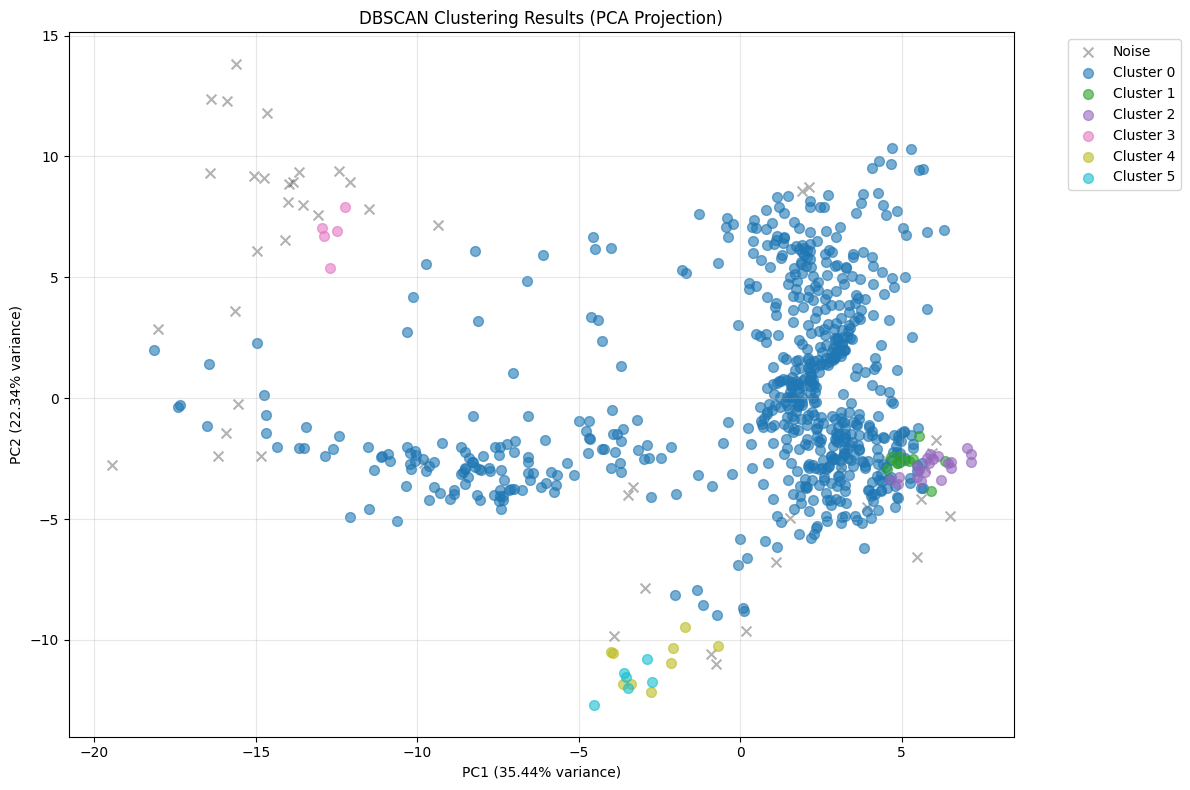


DBSCAN Cluster Summary:

Noise Points: 47

Cluster 0:
  Size: 675 locations
  Sample locations: Andhra Pradesh_Alluri Sitharama Raju, Andhra Pradesh_Anakapalli, Andhra Pradesh_Anantapur, Andhra Pradesh_Bapatla, Andhra Pradesh_East Godavari
  Avg annual rainfall: 1.41
  Avg annual temp: 297.83 K
  Avg PCI: 18.49

Cluster 1:
  Size: 11 locations
  Sample locations: Andhra Pradesh_Annamayya, Andhra Pradesh_Chittoor, Tamil Nadu_Kallakurichi, Tamil Nadu_Karur, Tamil Nadu_Madurai
  Avg annual rainfall: 0.96
  Avg annual temp: 300.80 K
  Avg PCI: 12.21

Cluster 2:
  Size: 20 locations
  Sample locations: Andhra Pradesh_Spsr Nellore, Andhra Pradesh_Tirupati, Puducherry_Karaikal, Puducherry_Pondicherry, Tamil Nadu_Ariyalur
  Avg annual rainfall: 1.08
  Avg annual temp: 301.64 K
  Avg PCI: 13.77

Cluster 3:
  Size: 5 locations
  Sample locations: Himachal Pradesh_Chamba, Himachal Pradesh_Kullu, Uttarakhand_Chamoli, Uttarakhand_Pithoragarh, Uttarakhand_Uttar Kashi
  Avg annual rainfall: 1.60
  A

In [56]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1], axis=0)

dbscan = DBSCAN(eps=5, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Evaluate DBSCAN
mask_dbscan = dbscan_labels != -1
X_filtered_dbscan = X_scaled[mask_dbscan]
labels_filtered_dbscan = dbscan_labels[mask_dbscan]

n_clusters_dbscan = len(np.unique(labels_filtered_dbscan))
n_noise = np.sum(dbscan_labels == -1)

print("\nDBSCAN Evaluation:")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")

if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_filtered_dbscan, labels_filtered_dbscan)
    dbscan_davies_bouldin = davies_bouldin_score(X_filtered_dbscan, labels_filtered_dbscan)
    dbscan_calinski_harabasz = calinski_harabasz_score(X_filtered_dbscan, labels_filtered_dbscan)
    
    print(f"  Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"  Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
    print(f"  Calinski-Harabasz Index: {dbscan_calinski_harabasz:.2f}")

# Visualize DBSCAN with PCA
pca_dbscan = PCA(n_components=2)
X_pca_dbscan = pca_dbscan.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

unique_labels_dbscan = np.unique(dbscan_labels)
n_clusters_plot = len(unique_labels_dbscan[unique_labels_dbscan != -1])
colors_dbscan = plt.cm.tab10(np.linspace(0, 1, n_clusters_plot))

for i, label in enumerate(unique_labels_dbscan):
    if label == -1:
        color = 'black'
        marker = 'x'
        alpha = 0.3
        label_name = 'Noise'
    else:
        color = colors_dbscan[label % len(colors_dbscan)]
        marker = 'o'
        alpha = 0.6
        label_name = f'Cluster {label}'
    
    mask = dbscan_labels == label
    plt.scatter(X_pca_dbscan[mask, 0], X_pca_dbscan[mask, 1], 
               c=[color], label=label_name, 
               alpha=alpha, marker=marker, s=50)

plt.xlabel(f'PC1 ({pca_dbscan.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_dbscan.explained_variance_ratio_[1]:.2%} variance)')
plt.title('DBSCAN Clustering Results (PCA Projection)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# DBSCAN cluster summary
dbscan_df = features_df.copy()
dbscan_df['cluster'] = dbscan_labels

print("\nDBSCAN Cluster Summary:")
print("=" * 60)

if n_noise > 0:
    print(f"\nNoise Points: {n_noise}")

for cluster_id in sorted(dbscan_df['cluster'].unique()):
    if cluster_id == -1:
        continue
    cluster_data = dbscan_df[dbscan_df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} locations")
    print(f"  Sample locations: {', '.join(cluster_data['location'].head(5).values)}")
    print(f"  Avg annual rainfall: {cluster_data['tp_annual_total'].mean():.2f}")
    print(f"  Avg annual temp: {cluster_data['t2m_annual_mean'].mean():.2f} K")
    print(f"  Avg PCI: {cluster_data['tp_PCI'].mean():.2f}")
